# Задача 06A. Классификация табличных данных

Требуется решить задачу классификации на наборе данных, представленных в виде таблице, с использованием каждого из следующих методов

1) One rule

2) Логистическая регрессия

3) k ближайших соседей

4) Наивный байесовский классификатор

5) Деревья решений

6) Градиентный бустинг

7) Метод опорных векторов

8) Полносвязная нейронная сеть (multi layer perceptron)

9) Ансамбль моделей

Требуется провести предобработку данных, сравнительный анализ использованных методов и исследование важности признаков в датасете.

https://www.kaggle.com/datasets/uciml/forest-cover-type-dataset/data

In [1]:
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA 
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import plotly as py
import plotly.graph_objs as go
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot

In [2]:
df = pd.read_csv("covtype.csv")

In [3]:
X = df.copy()

In [4]:
X["Distance_To_Hydrology"] = ( (X["Horizontal_Distance_To_Hydrology"] ** 2) + (X["Vertical_Distance_To_Hydrology"] ** 2) ) ** (0.5)
X.drop(["Horizontal_Distance_To_Hydrology","Vertical_Distance_To_Hydrology"], axis=1, inplace=True)

In [5]:
X.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Wilderness_Area2,...,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type,Distance_To_Hydrology
0,2596,51,3,510,221,232,148,6279,1,0,...,0,0,0,0,0,0,0,0,5,258.000000
1,2590,56,2,390,220,235,151,6225,1,0,...,0,0,0,0,0,0,0,0,5,212.084889
2,2804,139,9,3180,234,238,135,6121,1,0,...,0,0,0,0,0,0,0,0,2,275.769832
3,2785,155,18,3090,238,238,122,6211,1,0,...,0,0,0,0,0,0,0,0,2,269.235956
4,2595,45,2,391,220,234,150,6172,1,0,...,0,0,0,0,0,0,0,0,5,153.003268


In [6]:
numer = X[["Elevation","Aspect","Slope","Horizontal_Distance_To_Roadways","Hillshade_9am","Hillshade_Noon","Hillshade_3pm","Horizontal_Distance_To_Fire_Points","Distance_To_Hydrology"]]

In [7]:
cater = X[["Wilderness_Area1","Wilderness_Area2","Wilderness_Area3","Wilderness_Area4","Soil_Type1","Soil_Type2","Soil_Type3","Soil_Type4","Soil_Type5","Soil_Type6","Soil_Type7","Soil_Type8","Soil_Type9","Soil_Type10","Soil_Type11","Soil_Type12","Soil_Type13","Soil_Type14","Soil_Type15","Soil_Type16","Soil_Type17","Soil_Type18","Soil_Type19","Soil_Type20","Soil_Type21","Soil_Type22","Soil_Type23","Soil_Type24","Soil_Type25","Soil_Type26","Soil_Type27","Soil_Type28","Soil_Type29","Soil_Type30","Soil_Type31","Soil_Type32","Soil_Type33","Soil_Type34","Soil_Type35","Soil_Type36","Soil_Type37","Soil_Type38","Soil_Type39","Soil_Type40","Cover_Type"]]

In [8]:
scaler = StandardScaler()

In [9]:
numer = pd.DataFrame(scaler.fit_transform(numer))

In [10]:
numer.columns = ["Elevation_Scaled","Aspect_Scaled","Slope_Scaled","Horizontal_Distance_To_Roadways_Scaled","Hillshade_9am_Scaled","Hillshade_Noon_Scaled","Hillshade_3pm_Scaled","Horizontal_Distance_To_Fire_Points_Scaled","Distance_To_Hydrology_Scaled"]

In [11]:
X = pd.concat([numer, cater], axis=1, join='inner')

In [12]:
X.head()

,Elevation_Scaled,Aspect_Scaled,Slope_Scaled,Horizontal_Distance_To_Roadways_Scaled,Hillshade_9am_Scaled,Hillshade_Noon_Scaled,Hillshade_3pm_Scaled,Horizontal_Distance_To_Fire_Points_Scaled,Distance_To_Hydrology_Scaled,Wilderness_Area1,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,-1.297805,-0.935157,-1.482820,-1.180146,0.330743,0.439143,0.142960,3.246283,-0.083233,1,...,0,0,0,0,0,0,0,0,0,5
1,-1.319235,-0.890480,-1.616363,-1.257106,0.293388,0.590899,0.221342,3.205504,-0.294777,1,...,0,0,0,0,0,0,0,0,0,5
2,-0.554907,-0.148836,-0.681563,0.532212,0.816364,0.742654,-0.196691,3.126965,-0.001362,1,...,0,0,0,0,0,0,0,0,0,2
3,-0.622768,-0.005869,0.520322,0.474492,0.965786,0.742654,-0.536343,3.194931,-0.031466,1,...,0,0,0,0,0,0,0,0,0,2
4,-1.301377,-0.988770,-1.616363,-1.256464,0.293388,0.540313,0.195215,3.165479,-0.566983,1,...,0,0,0,0,0,0,0,0,0,5


one rule

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

df = pd.read_csv('covtype.csv')  # путь к датасету

X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

# Дискретизация числовых признаков (например, 10 бинов)
X_binned = X.copy()
for col in X.columns:
    X_binned[col] = pd.qcut(X[col], q=10, duplicates='drop').astype(str)

X_train, X_test, y_train, y_test = train_test_split(X_binned, y, test_size=0.2, random_state=42)

# Реализация One Rule
best_feature = None
lowest_error = float('inf')
rules = {}

for col in X_train.columns:
    rule = {}
    errors = 0
    for val in X_train[col].unique():
        # Определяем самый частый класс для этого значения признака
        mask = X_train[col] == val
        most_common = y_train[mask].mode()[0]
        rule[val] = most_common
        errors += sum(y_train[mask] != most_common)

    if errors < lowest_error:
        best_feature = col
        lowest_error = errors
        rules = rule

print(f"Лучшая переменная по OneR: {best_feature}")
print(f"Правила: {rules}")

y_pred = X_test[best_feature].map(rules)
y_pred.fillna(y_train.mode()[0], inplace=True)  # на случай, если новое значение

print("Точность:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Лучшая переменная по OneR: Elevation
Правила: {'(3272.0, 3858.0]': np.int64(1), '(2938.0, 2996.0]': np.int64(2), '(2996.0, 3059.0]': np.int64(2), '(3059.0, 3129.0]': np.int64(1), '(2751.0, 2860.0]': np.int64(2), '(3129.0, 3198.0]': np.int64(1), '(2860.0, 2938.0]': np.int64(2), '(1858.999, 2581.0]': np.int64(3), '(3198.0, 3272.0]': np.int64(1), '(2581.0, 2751.0]': np.int64(2)}
Точность: 0.6629519031350309
              precision    recall  f1-score   support

           1       0.64      0.70      0.67     42557
           2       0.71      0.73      0.72     56500
           3       0.50      0.80      0.61      7121
           4       0.00      0.00      0.00       526
           5       0.00      0.00      0.00      1995
           6       0.00      0.00      0.00      3489
           7       0.00      0.00      0.00      4015

    accuracy                           0.66    116203
   macro avg       0.26      0.32      0.29    116203
weighted avg       0.61      0.66      0.63    116

C:\Users\maxim\anaconda3\envs\neural-networks\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\maxim\anaconda3\envs\neural-networks\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\maxim\anaconda3\envs\neural-networks\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [1]:
# предобработка в 1 ячейке
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("covtype.csv")

y = df["Cover_Type"]
X = df.drop("Cover_Type", axis=1)

X["Distance_To_Hydrology"] = np.sqrt(
    X["Horizontal_Distance_To_Hydrology"]**2 + X["Vertical_Distance_To_Hydrology"]**2
)

X.drop(["Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology"], axis=1, inplace=True)

numerical_features = [
    "Elevation", "Aspect", "Slope", "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points", "Distance_To_Hydrology"
]

categorical_features = [col for col in X.columns if col not in numerical_features]

scaler = StandardScaler()
X_numerical_scaled = pd.DataFrame(scaler.fit_transform(X[numerical_features]),
                                  columns=[f"{col}_Scaled" for col in numerical_features])

X_final = pd.concat([X_numerical_scaled, X[categorical_features].reset_index(drop=True)], axis=1)

In [2]:
# вынесем разбиение в отдельную ячейку
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "8"

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

# Балансировка только для обучения
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

history_log = []

In [5]:
import os
import pickle

In [8]:
import datetime
HISTORY_DIR = './history'
os.makedirs(HISTORY_DIR, exist_ok=True)
logdir = os.path.join(HISTORY_DIR, datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
os.makedirs(logdir, exist_ok=True)

# One rule

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import KBinsDiscretizer
from collections import defaultdict

# OneR: найдем лучший признак
best_feature = None
best_accuracy = 0
best_rules = {}
best_bins = None
n_bins = 20  # Количество бинов (можно варьировать)

for feature in X_train_balanced.columns:
    # Дискретизация признака
    est = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
    binned = est.fit_transform(X_train_balanced[[feature]])
    bins = est.bin_edges_[0]

    # Создание правил: для каждого бина выбираем наиболее частый класс
    rules = {}
    for bin_idx in range(n_bins):
        indices = np.where(binned[:, 0] == bin_idx)[0]
        if len(indices) == 0:
            continue
        majority_class = y_train_balanced.iloc[indices].mode()[0]
        rules[bin_idx] = majority_class

    # Применение правил к train
    train_preds = [rules[int(bin_val)] if int(bin_val) in rules else -1 for bin_val in binned[:, 0]]
    acc = accuracy_score(y_train_balanced, train_preds)

    if acc > best_accuracy:
        best_accuracy = acc
        best_feature = feature
        best_rules = rules
        best_bins = bins

# Применим лучшие правила на тесте
# Дискретизация признака из теста
est = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
binned_test = est.fit(X_train_balanced[[best_feature]]).transform(X_test[[best_feature]])
test_preds = [best_rules.get(int(bin_val), -1) for bin_val in binned_test[:, 0]]

acc_oner = accuracy_score(y_test, test_preds)
report_oner = classification_report(y_test, test_preds, output_dict=True, zero_division=0)

history_log.append({
    "Model": "One Rule (OneR)",
    "Accuracy": acc_oner,
    "Precision_macro": report_oner["macro avg"]["precision"],
    "Recall_macro": report_oner["macro avg"]["recall"],
    "F1_macro": report_oner["macro avg"]["f1-score"]
})

print(f"Лучшая переменная по OneR: {best_feature}")
print(f"Правила: {best_rules}")
print(f"Accuracy: {acc_oner}")
print("\nClassification report:\n")
print(classification_report(y_test, test_preds, zero_division=0))

history_df = pd.DataFrame(history_log)
display(history_df)

oner_model = {
    "feature": best_feature,
    "rules": best_rules,
    "bins": best_bins,
    "n_bins": n_bins
}

# --- Сохранение модели ---
oner_model_path = os.path.join(logdir, "One_rule.pkl")
with open(oner_model_path, "wb") as f:
    pickle.dump(oner_model, f)

print(f"OneR-модель сохранена в: {oner_model_path}")

C:\Users\maxim\anaconda3\envs\neural-networks\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\neural-networks\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\neural-networks\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\neural-networks\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  war

Лучшая переменная по OneR: Elevation_Scaled
Правила: {0: np.int64(4), 1: np.int64(4), 2: np.int64(4), 3: np.int64(4), 4: np.int64(4), 5: np.int64(6), 6: np.int64(6), 7: np.int64(3), 8: np.int64(3), 9: np.int64(5), 10: np.int64(5), 11: np.int64(5), 12: np.int64(5), 13: np.int64(2), 14: np.int64(1), 15: np.int64(1), 16: np.int64(1), 17: np.int64(7), 18: np.int64(7), 19: np.int64(7)}
Accuracy: 0.3937419860072459

Classification report:

              precision    recall  f1-score   support

           1       0.60      0.62      0.61     42368
           2       0.71      0.19      0.30     56661
           3       0.19      0.27      0.23      7151
           4       0.10      0.94      0.19       549
           5       0.06      0.81      0.11      1899
           6       0.33      0.36      0.34      3473
           7       0.28      0.84      0.42      4102

    accuracy                           0.39    116203
   macro avg       0.32      0.58      0.31    116203
weighted avg       0

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,One Rule (OneR),0.395601,0.326132,0.577368,0.315699
1,One Rule (OneR),0.393742,0.324760,0.577175,0.313496


OneR-модель сохранена в: ./history\20250529-224108\One_rule.pkl


# Логистическая регрессия

In [3]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report, accuracy_score

# log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
# log_reg.fit(X_train_balanced, y_train_balanced)

# y_pred = log_reg.predict(X_test)

# print("Accuracy (точность):", accuracy_score(y_test, y_pred))
# print("\nClassification report:\n")
# print(classification_report(y_test, y_pred, zero_division=0))

C:\Users\maxim\anaconda3\envs\neural-networks\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


KeyboardInterrupt: 

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import sys
sys.stdout.flush()

log_reg = LogisticRegression(
    solver='saga',
    max_iter=1000,
    random_state=42,
    verbose=1
)

log_reg.fit(X_train_balanced, y_train_balanced)

y_pred = log_reg.predict(X_test)

acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

history_log.append({
    "Model": "Logistic Regression",
    "Accuracy": acc,
    "Precision_macro": report["macro avg"]["precision"],
    "Recall_macro": report["macro avg"]["recall"],
    "F1_macro": report["macro avg"]["f1-score"]
})

print("Logistic Regression")
print("Accuracy (точность):", acc)
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

history_df = pd.DataFrame(history_log)
display(history_df)

# --- Сохранение модели ---
log_reg_path = os.path.join(logdir, "LogisticRegression.pkl")
with open(log_reg_path, "wb") as f:
    pickle.dump(log_reg, f)

print(f"Модель Logistic Regression сохранена в: {log_reg_path}")

convergence after 376 epochs took 1487 seconds
Logistic Regression
Accuracy (точность): 0.5989948624390076

Classification report:

              precision    recall  f1-score   support

           1       0.68      0.66      0.67     42368
           2       0.79      0.52      0.63     56661
           3       0.70      0.57      0.63      7151
           4       0.29      0.88      0.44       549
           5       0.10      0.78      0.18      1899
           6       0.34      0.66      0.45      3473
           7       0.40      0.89      0.56      4102

    accuracy                           0.60    116203
   macro avg       0.47      0.71      0.51    116203
weighted avg       0.70      0.60      0.63    116203



,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,One Rule (OneR),0.395601,0.326132,0.577368,0.315699
1,One Rule (OneR),0.393742,0.324760,0.577175,0.313496
2,Logistic Regression,0.598995,0.472484,0.708351,0.507440


Модель Logistic Regression сохранена в: ./history\20250529-224108\LogisticRegression.pkl


Logistic Regression
Accuracy (точность): 0.5985731865786598

Classification report:

              precision    recall  f1-score   support

           1       0.68      0.66      0.67     42368
           2       0.79      0.52      0.63     56661
           3       0.70      0.57      0.63      7151
           4       0.29      0.88      0.44       549
           5       0.10      0.78      0.18      1899
           6       0.34      0.66      0.45      3473
           7       0.40      0.89      0.56      4102

    accuracy                           0.60    116203
   macro avg       0.47      0.71      0.51    116203
weighted avg       0.70      0.60      0.63    116203



,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,One Rule (OneR),0.392778,0.324326,0.57701,0.313079
1,Logistic Regression,0.598573,0.472323,0.70826,0.507261


# K-ближайших соседей

K-Nearest Neighbors Classifier
Accuracy: 0.9135220261094809

Classification Report:

              precision    recall  f1-score   support

           1       0.92      0.92      0.92     42368
           2       0.95      0.91      0.93     56661
           3       0.89      0.91      0.90      7151
           4       0.78      0.85      0.81       549
           5       0.59      0.94      0.73      1899
           6       0.76      0.88      0.82      3473
           7       0.87      0.97      0.92      4102

    accuracy                           0.91    116203
   macro avg       0.82      0.91      0.86    116203
weighted avg       0.92      0.91      0.91    116203



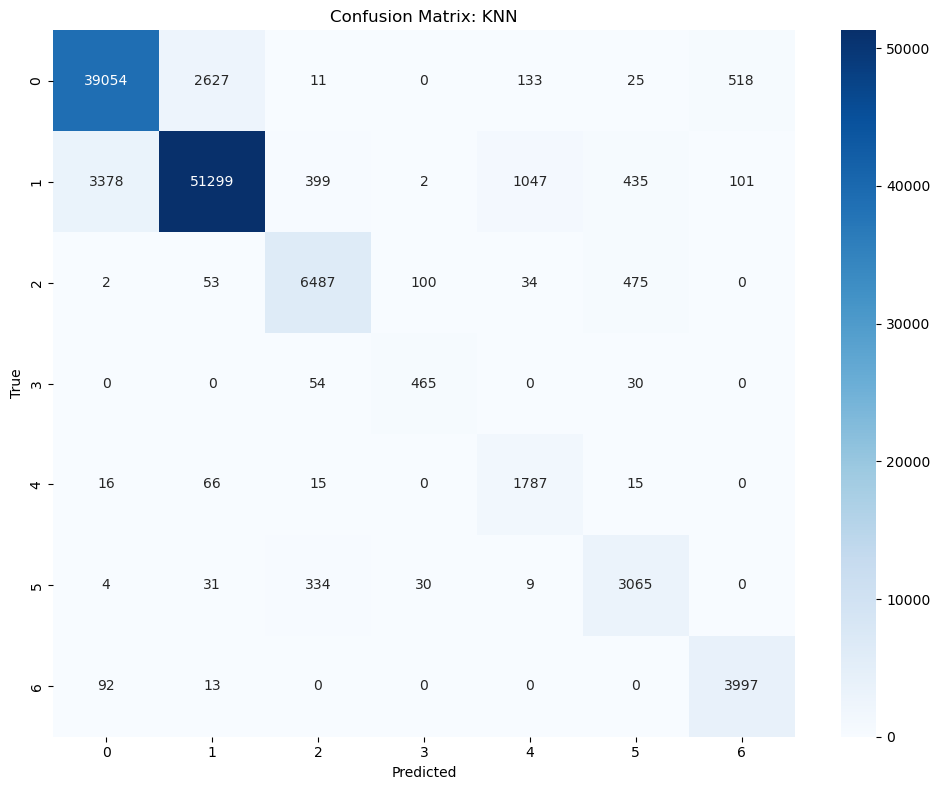

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,One Rule (OneR),0.392778,0.324326,0.577010,0.313079
1,Logistic Regression,0.598573,0.472323,0.708260,0.507261
2,K-Nearest Neighbors,0.913522,0.821597,0.911319,0.859419


In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)  # n_jobs=-1 — использовать все ядра
knn.fit(X_train_balanced, y_train_balanced)

y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
report_knn = classification_report(y_test, y_pred_knn, output_dict=True, zero_division=0)

history_log.append({
    "Model": "K-Nearest Neighbors",
    "Accuracy": acc_knn,
    "Precision_macro": report_knn["macro avg"]["precision"],
    "Recall_macro": report_knn["macro avg"]["recall"],
    "F1_macro": report_knn["macro avg"]["f1-score"]
})

print("K-Nearest Neighbors Classifier")
print("Accuracy:", acc_knn)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn, zero_division=0))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: KNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

history_df = pd.DataFrame(history_log)
display(history_df)

# --- Сохранение модели ---
os.makedirs(logdir, exist_ok=True)

knn_model_path = os.path.join(logdir, "KNN.pkl")
with open(knn_model_path, "wb") as f:
    pickle.dump(knn, f)

print(f"Модель KNN сохранена в: {knn_model_path}")

# Наивный байесовский классификатор

In [10]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# Создаем модель
nb_classifier = GaussianNB()

# Обучаем на сбалансированных данных
nb_classifier.fit(X_train_balanced, y_train_balanced)

# Предсказания на тесте
y_pred_nb = nb_classifier.predict(X_test)

# Метрики
acc_nb = accuracy_score(y_test, y_pred_nb)
report_nb = classification_report(y_test, y_pred_nb, output_dict=True, zero_division=0)

# Логируем результаты
history_log.append({
    "Model": "Naive Bayes",
    "Accuracy": acc_nb,
    "Precision_macro": report_nb["macro avg"]["precision"],
    "Recall_macro": report_nb["macro avg"]["recall"],
    "F1_macro": report_nb["macro avg"]["f1-score"]
})

print("Наивный Байесовский классификатор")
print("Accuracy (точность):", acc_nb)
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_nb, zero_division=0))

# Отобразим обновленный лог
history_df = pd.DataFrame(history_log)
display(history_df)

# --- Сохранение модели ---
os.makedirs(logdir, exist_ok=True)  # Убедимся, что папка существует

nb_model_path = os.path.join(logdir, "NaiveBayes.pkl")
with open(nb_model_path, "wb") as f:
    pickle.dump(nb_classifier, f)

print(f"Модель Naive Bayes сохранена в: {nb_model_path}")

Наивный Байесовский классификатор
Accuracy (точность): 0.11018648399783137

Classification report:

              precision    recall  f1-score   support

           1       0.25      0.03      0.06     42368
           2       0.86      0.04      0.08     56661
           3       0.30      0.40      0.34      7151
           4       0.07      1.00      0.14       549
           5       0.03      0.74      0.05      1899
           6       0.17      0.08      0.11      3473
           7       0.11      0.95      0.20      4102

    accuracy                           0.11    116203
   macro avg       0.26      0.46      0.14    116203
weighted avg       0.54      0.11      0.09    116203



,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,One Rule (OneR),0.392778,0.324326,0.577010,0.313079
1,Logistic Regression,0.598573,0.472323,0.708260,0.507261
2,K-Nearest Neighbors,0.913522,0.821597,0.911319,0.859419
3,Naive Bayes,0.110186,0.255400,0.464488,0.140395


# Деревья решений

In [11]:
from sklearn.tree import DecisionTreeClassifier

# Создаем модель
dt_classifier = DecisionTreeClassifier(random_state=42)

# Обучаем на сбалансированных данных
dt_classifier.fit(X_train_balanced, y_train_balanced)

# Предсказания на тесте
y_pred_dt = dt_classifier.predict(X_test)

# Метрики
acc_dt = accuracy_score(y_test, y_pred_dt)
report_dt = classification_report(y_test, y_pred_dt, output_dict=True, zero_division=0)

# Логируем результаты
history_log.append({
    "Model": "Decision Tree",
    "Accuracy": acc_dt,
    "Precision_macro": report_dt["macro avg"]["precision"],
    "Recall_macro": report_dt["macro avg"]["recall"],
    "F1_macro": report_dt["macro avg"]["f1-score"]
})

print("Дерево решений")
print("Accuracy (точность):", acc_dt)
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_dt, zero_division=0))

history_df = pd.DataFrame(history_log)
display(history_df)

# --- Сохранение модели ---
os.makedirs(logdir, exist_ok=True) 

dt_model_path = os.path.join(logdir, "DecisionTree.pkl")
with open(dt_model_path, "wb") as f:
    pickle.dump(dt_classifier, f)

print(f"Модель Decision Tree сохранена в: {dt_model_path}")

Дерево решений
Accuracy (точность): 0.9329965663537086

Classification report:

              precision    recall  f1-score   support

           1       0.93      0.93      0.93     42368
           2       0.95      0.94      0.94     56661
           3       0.91      0.93      0.92      7151
           4       0.84      0.86      0.85       549
           5       0.77      0.87      0.82      1899
           6       0.85      0.88      0.86      3473
           7       0.93      0.95      0.94      4102

    accuracy                           0.93    116203
   macro avg       0.88      0.91      0.90    116203
weighted avg       0.93      0.93      0.93    116203



,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,One Rule (OneR),0.392778,0.324326,0.577010,0.313079
1,Logistic Regression,0.598573,0.472323,0.708260,0.507261
2,K-Nearest Neighbors,0.913522,0.821597,0.911319,0.859419
3,Naive Bayes,0.110186,0.255400,0.464488,0.140395
4,Decision Tree,0.932997,0.883674,0.908456,0.895582


# Градиентный бустинг

In [13]:
print("Размер X_train_balanced:", X_train_balanced.shape)
print("Распределение классов:", np.bincount(y_train_balanced - 1))

Размер X_train_balanced: (1586480, 53)
Распределение классов: [226640 226640 226640 226640 226640 226640 226640]


In [15]:
from sklearn.ensemble import GradientBoostingClassifier

gb_classifier = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    subsample=0.8,
    verbose=1,
    random_state=42
)

gb_classifier.fit(X_train_balanced, y_train_balanced)

y_pred_gb = gb_classifier.predict(X_test)

acc_gb = accuracy_score(y_test, y_pred_gb)
report_gb = classification_report(y_test, y_pred_gb, output_dict=True, zero_division=0)

history_log.append({
    "Model": "Gradient Boosting",
    "Accuracy": acc_gb,
    "Precision_macro": report_gb["macro avg"]["precision"],
    "Recall_macro": report_gb["macro avg"]["recall"],
    "F1_macro": report_gb["macro avg"]["f1-score"]
})

print("Градиентный бустинг")
print("Accuracy (точность):", acc_gb)
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_gb, zero_division=0))

history_df = pd.DataFrame(history_log)
display(history_df)

# --- Сохранение модели ---
os.makedirs(logdir, exist_ok=True)  # Убедимся, что папка существует

gb_model_path = os.path.join(logdir, "GradientBoosting.pkl")
with open(gb_model_path, "wb") as f:
    pickle.dump(gb_classifier, f)

print(f"Модель Gradient Boosting сохранена в: {gb_model_path}")

      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.7132           0.2328           99.88m
         2           1.5437           0.1698          100.07m
         3           1.4172           0.1270           96.65m
         4           1.3253           0.0919           94.64m
         5           1.2413           0.0833           92.71m
         6           1.1723           0.0680           90.21m
         7           1.1149           0.0569           87.75m
         8           1.0629           0.0541           85.73m
         9           1.0188           0.0443           83.94m
        10           0.9825           0.0353           82.43m
        20           0.7665           0.0128           72.06m
        30           0.6770           0.0067           62.23m
        40           0.6269           0.0032           53.13m
        50           0.5911           0.0023           44.14m
        60           0.5637           0.0053           35.25m
       

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,One Rule (OneR),0.392778,0.324326,0.577010,0.313079
1,Logistic Regression,0.598573,0.472323,0.708260,0.507261
2,K-Nearest Neighbors,0.913522,0.821597,0.911319,0.859419
3,Naive Bayes,0.110186,0.255400,0.464488,0.140395
4,Decision Tree,0.932997,0.883674,0.908456,0.895582
5,Gradient Boosting,0.673726,0.555783,0.806530,0.614585


# Метод опорных векторов

In [ ]:
from sklearn.svm import SVC

svm_classifier = SVC(random_state=42)
svm_classifier.fit(X_train_balanced, y_train_balanced)

y_pred_svm = svm_classifier.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm, output_dict=True, zero_division=0)

history_log.append({
    "Model": "SVM",
    "Accuracy": acc_svm,
    "Precision_macro": report_svm["macro avg"]["precision"],
    "Recall_macro": report_svm["macro avg"]["recall"],
    "F1_macro": report_svm["macro avg"]["f1-score"]
})

print("Метод опорных векторов")
print("Accuracy (точность):", acc_svm)
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_svm, zero_division=0))

display(pd.DataFrame(history_log))

# --- Сохранение модели ---
os.makedirs(logdir, exist_ok=True)  # Убедимся, что папка существует

svm_model_path = os.path.join(logdir, "SVM.pkl")
with open(svm_model_path, "wb") as f:
    pickle.dump(svm_classifier, f)

print(f"Модель SVM сохранена в: {svm_model_path}")

# Полносвязная нейронная сеть (multi layer perceptron)

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_classifier = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
mlp_classifier.fit(X_train_balanced, y_train_balanced)

y_pred_mlp = mlp_classifier.predict(X_test)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
report_mlp = classification_report(y_test, y_pred_mlp, output_dict=True, zero_division=0)

history_log.append({
    "Model": "MLP",
    "Accuracy": acc_mlp,
    "Precision_macro": report_mlp["macro avg"]["precision"],
    "Recall_macro": report_mlp["macro avg"]["recall"],
    "F1_macro": report_mlp["macro avg"]["f1-score"]
})

print("Полносвязная нейронная сеть")
print("Accuracy (точность):", acc_mlp)
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_mlp, zero_division=0))

display(pd.DataFrame(history_log))

# --- Сохранение модели ---
os.makedirs(logdir, exist_ok=True)  # Убедимся, что папка существует

mlp_model_path = os.path.join(logdir, "MLP.pkl")
with open(mlp_model_path, "wb") as f:
    pickle.dump(mlp_classifier, f)

print(f"Модель MLP сохранена в: {mlp_model_path}")

# Ансамбль моделей

In [ ]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('dt', dt_classifier),
        ('gb', gb_classifier),
        ('mlp', mlp_classifier)
    ],
    voting='hard'
)

ensemble.fit(X_train_balanced, y_train_balanced)
y_pred_ensemble = ensemble.predict(X_test)

acc_ensemble = accuracy_score(y_test, y_pred_ensemble)
report_ensemble = classification_report(y_test, y_pred_ensemble, output_dict=True, zero_division=0)

history_log.append({
    "Model": "Ensemble",
    "Accuracy": acc_ensemble,
    "Precision_macro": report_ensemble["macro avg"]["precision"],
    "Recall_macro": report_ensemble["macro avg"]["recall"],
    "F1_macro": report_ensemble["macro avg"]["f1-score"]
})

print("Ансамбль моделей")
print("Accuracy (точность):", acc_ensemble)
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_ensemble, zero_division=0))

display(pd.DataFrame(history_log))

# --- Сохранение ансамбля моделей ---
os.makedirs(logdir, exist_ok=True)  # Убедимся, что папка существует

ensemble_model_path = os.path.join(logdir, "Ensemble.pkl")
with open(ensemble_model_path, "wb") as f:
    pickle.dump(ensemble, f)

print(f"Модель ансамбля сохранена в: {ensemble_model_path}")

# Общая загрузка

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import KBinsDiscretizer
from collections import defaultdict

# OneR: найдем лучший признак
best_feature = None
best_accuracy = 0
best_rules = {}
best_bins = None
n_bins = 20  # Количество бинов (можно варьировать)

for feature in X_train_balanced.columns:
    # Дискретизация признака
    est = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
    binned = est.fit_transform(X_train_balanced[[feature]])
    bins = est.bin_edges_[0]

    # Создание правил: для каждого бина выбираем наиболее частый класс
    rules = {}
    for bin_idx in range(n_bins):
        indices = np.where(binned[:, 0] == bin_idx)[0]
        if len(indices) == 0:
            continue
        majority_class = y_train_balanced.iloc[indices].mode()[0]
        rules[bin_idx] = majority_class

    # Применение правил к train
    train_preds = [rules[int(bin_val)] if int(bin_val) in rules else -1 for bin_val in binned[:, 0]]
    acc = accuracy_score(y_train_balanced, train_preds)

    if acc > best_accuracy:
        best_accuracy = acc
        best_feature = feature
        best_rules = rules
        best_bins = bins

# Применим лучшие правила на тесте
# Дискретизация признака из теста
est = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
binned_test = est.fit(X_train_balanced[[best_feature]]).transform(X_test[[best_feature]])
test_preds = [best_rules.get(int(bin_val), -1) for bin_val in binned_test[:, 0]]

acc_oner = accuracy_score(y_test, test_preds)
report_oner = classification_report(y_test, test_preds, output_dict=True, zero_division=0)

history_log.append({
    "Model": "One Rule (OneR)",
    "Accuracy": acc_oner,
    "Precision_macro": report_oner["macro avg"]["precision"],
    "Recall_macro": report_oner["macro avg"]["recall"],
    "F1_macro": report_oner["macro avg"]["f1-score"]
})

print(f"Лучшая переменная по OneR: {best_feature}")
print(f"Правила: {best_rules}")
print(f"Accuracy: {acc_oner}")
print("\nClassification report:\n")
print(classification_report(y_test, test_preds, zero_division=0))

history_df = pd.DataFrame(history_log)
display(history_df)

oner_model = {
    "feature": best_feature,
    "rules": best_rules,
    "bins": best_bins,
    "n_bins": n_bins
}

# --- Сохранение модели ---
oner_model_path = os.path.join(logdir, "One_rule.pkl")
with open(oner_model_path, "wb") as f:
    pickle.dump(oner_model, f)

print(f"OneR-модель сохранена в: {oner_model_path}")


#------------------------------------------------------------------------------------------------------------------------------#
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import sys
sys.stdout.flush()

log_reg = LogisticRegression(
    solver='saga',
    max_iter=1000,
    random_state=42,
    verbose=1
)

log_reg.fit(X_train_balanced, y_train_balanced)

y_pred = log_reg.predict(X_test)

acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

history_log.append({
    "Model": "Logistic Regression",
    "Accuracy": acc,
    "Precision_macro": report["macro avg"]["precision"],
    "Recall_macro": report["macro avg"]["recall"],
    "F1_macro": report["macro avg"]["f1-score"]
})

print("Logistic Regression")
print("Accuracy (точность):", acc)
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

history_df = pd.DataFrame(history_log)
display(history_df)

# --- Сохранение модели ---
log_reg_path = os.path.join(logdir, "LogisticRegression.pkl")
with open(log_reg_path, "wb") as f:
    pickle.dump(log_reg, f)

print(f"Модель Logistic Regression сохранена в: {log_reg_path}")
#------------------------------------------------------------------------------------------------------------------------------#
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)  # n_jobs=-1 — использовать все ядра
knn.fit(X_train_balanced, y_train_balanced)

y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
report_knn = classification_report(y_test, y_pred_knn, output_dict=True, zero_division=0)

history_log.append({
    "Model": "K-Nearest Neighbors",
    "Accuracy": acc_knn,
    "Precision_macro": report_knn["macro avg"]["precision"],
    "Recall_macro": report_knn["macro avg"]["recall"],
    "F1_macro": report_knn["macro avg"]["f1-score"]
})

print("K-Nearest Neighbors Classifier")
print("Accuracy:", acc_knn)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn, zero_division=0))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: KNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

history_df = pd.DataFrame(history_log)
display(history_df)

# --- Сохранение модели ---
os.makedirs(logdir, exist_ok=True)

knn_model_path = os.path.join(logdir, "KNN.pkl")
with open(knn_model_path, "wb") as f:
    pickle.dump(knn, f)

print(f"Модель KNN сохранена в: {knn_model_path}")
#------------------------------------------------------------------------------------------------------------------------------#

#------------------------------------------------------------------------------------------------------------------------------#

#------------------------------------------------------------------------------------------------------------------------------#

#------------------------------------------------------------------------------------------------------------------------------#

#------------------------------------------------------------------------------------------------------------------------------#

#------------------------------------------------------------------------------------------------------------------------------#

#------------------------------------------------------------------------------------------------------------------------------#

#------------------------------------------------------------------------------------------------------------------------------#

#------------------------------------------------------------------------------------------------------------------------------#

#------------------------------------------------------------------------------------------------------------------------------#

#------------------------------------------------------------------------------------------------------------------------------#



In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import Binarizer
from sklearn.model_selection import train_test_split

# 1. Загружаем датасет
df = pd.read_csv('covtype.csv')  # Замените на путь к вашему файлу

# 2. Разделим на признаки и метки классов
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values - 1  # Преобразуем метки от 0 до 6

# 3. Бинаризация признаков (порог можно настроить)
binarizer = Binarizer(threshold=0.5)
X_bin = binarizer.fit_transform(X)

# 4. Разделим на train/test, но используем только train (чтобы имитировать обучение)
X_train, _, y_train, _ = train_test_split(X_bin, y, test_size=0.3, random_state=42)

# 5. Формируем input.txt
n, m = X_train.shape
k = len(np.unique(y_train))

with open('input.txt', 'w') as f:
    f.write(f"{n} {m} {k}\n")
    for xi, yi in zip(X_train, y_train):
        line = ' '.join(map(str, xi)) + f' {yi}\n'
        f.write(line)


In [ ]:
import numpy as np

def naive_bayes_classifier(input_path, output_path):
    with open(input_path, 'r') as f:
        n, m, k = map(int, f.readline().strip().split())
        data = np.array([list(map(int, line.strip().split())) for line in f])

    features, true_classes = data[:, :-1], data[:, -1]

    class_counts = np.ones(k)
    word_counts = np.ones((k, m))

    predictions = np.empty(n, dtype=int)

    for i, (x, y) in enumerate(zip(features, true_classes)):
        log_probs = np.log(class_counts) - np.log(class_counts.sum())
        log_probs += (np.log(word_counts[:, x == 1]) - np.log(word_counts.sum(axis=1, keepdims=True))).sum(axis=1)
        predictions[i] = np.argmax(log_probs)

        class_counts[y] += 1
        word_counts[y] += x

    with open(output_path, 'w') as f:
        f.write('\n'.join(map(str, predictions)))

# Запускаем классификатор
naive_bayes_classifier('input.txt', 'output.txt')


In [ ]:
from sklearn.metrics import accuracy_score

# Считаем предсказания
with open('output.txt') as f:
    y_pred = [int(line.strip()) for line in f]

# Истинные метки
true_classes = np.loadtxt('input.txt', skiprows=1, usecols=-1, dtype=int)

# Оценка точности
acc = accuracy_score(true_classes, y_pred)
print(f"Accuracy: {acc:.4f}")
